# Operator-resolved transport

For a BdG (Nambu) junction, `.didv(energy, component=...)` decomposes the total conductance into
its normal (electron-transmission) and Andreev-reflection contributions --
`component="electron"`/`component="Andreev"` project the scattering process onto the
electron/hole Nambu sectors before evaluating the conductance, rather than tracing over the full
Nambu space at once. Below, a normal/superconductor junction's total conductance is split into
these two operator-resolved components, showing how sub-gap transport is carried entirely by
Andreev reflection while above-gap transport is dominated by ordinary electron transmission.

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import heterostructures

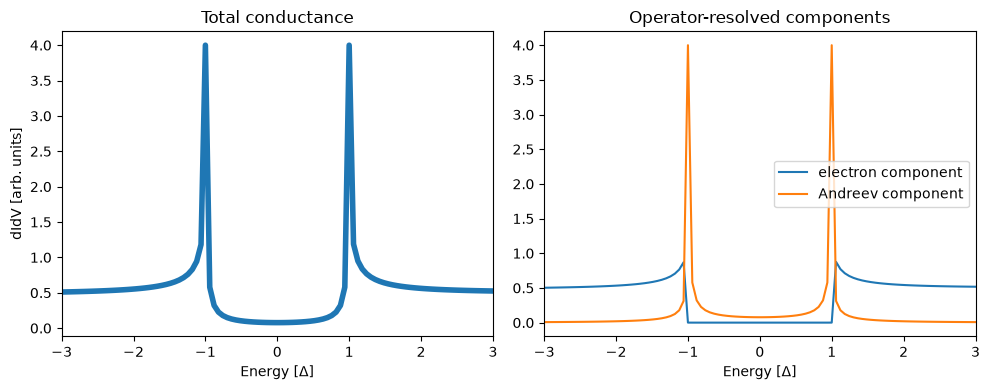

In [2]:
g = geometry.chain()
h = g.get_hamiltonian()
h.add_onsite(1.0)
h1 = h.copy() # normal lead
h2 = h.copy() # superconducting lead
delta = 0.01
h2.add_swave(delta)
HT = heterostructures.build(h1,h2)
T = 0.3
HT.set_coupling(T)
es = np.linspace(-.03,.03,100)

G  = [HT.didv(energy=e) for e in es]
Ge = [HT.didv(energy=e,component="electron") for e in es]
Gh = [HT.didv(energy=e,component="Andreev") for e in es]

fig,axs = plt.subplots(1,2,figsize=(10,4))
axs[0].plot(es/delta,G,linewidth=4)
axs[0].set_title("Total conductance") ; axs[0].set_xlabel("Energy [$\Delta$]")
axs[0].set_ylabel("dIdV [arb. units]") ; axs[0].set_xlim([-3,3])
axs[1].plot(es/delta,Ge,label="electron component")
axs[1].plot(es/delta,Gh,label="Andreev component")
axs[1].set_title("Operator-resolved components") ; axs[1].set_xlabel("Energy [$\Delta$]")
axs[1].legend() ; axs[1].set_xlim([-3,3])
plt.tight_layout()
plt.show()